NB to explore the CA MPA fisheries hypothesis 



In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


In [2]:
# import MPA data data/California_Marine_Protected_Areas_[ds582].geojson

gdf = gpd.read_file("data/California_Marine_Protected_Areas_[ds582].geojson")
gdf.head()

,OBJECTID,NAME,CCR,Area_sq_mi,Study_Regi,FULLNAME,Type,CCR_Int,SHORTNAME,Acres,Hectares,Shape__Area,Shape__Length,geometry
0,1,Pyramid Point SMCA,Section 632 (b) (1),13.993556,NCSR,Pyramid Point State Marine Conservation Area,SMCA,1,Pyramid Point,8955.911523,3624.328806,6.563464e+07,36841.209956,"POLYGON ((-124.20707 41.95834, -124.28504 41.9..."
1,2,Point St. George Reef Offshore SMCA,Section 632 (b) (2),9.523240,NCSR,Point St. George Reef Offshore State Marine Co...,SMCA,2,Point St. George Reef Offshore,6094.897977,2466.517702,4.447399e+07,25879.581674,"POLYGON ((-124.4301 41.86667, -124.3865 41.866..."
2,3,Southwest Seal Rock Special Closure,Section 632 (b) (3),0.022345,NCSR,Southwest Seal Rock Special Closure,Special Closure,3,Southwest Seal Rock,14.300739,5.787304,1.042612e+05,1638.296108,"POLYGON ((-124.35062 41.81434, -124.35061 41.8..."
3,4,Castle Rock Special Closure,Section 632 (b) (4),0.053771,NCSR,Castle Rock Special Closure,Special Closure,4,Castle Rock,34.413482,13.926642,2.504891e+05,3697.977977,"POLYGON ((-124.24911 41.76326, -124.24904 41.7..."
4,5,False Klamath Rock Special Closure,Section 632 (b) (5),0.026791,NCSR,False Klamath Rock Special Closure,Special Closure,5,False Klamath Rock,17.145992,6.938737,1.241596e+05,2005.228679,"POLYGON ((-124.11147 41.59521, -124.11129 41.5..."


In [4]:
gdf.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   OBJECTID       155 non-null    int32   
 1   NAME           155 non-null    str     
 2   CCR            155 non-null    str     
 3   Area_sq_mi     155 non-null    float64 
 4   Study_Regi     155 non-null    str     
 5   FULLNAME       155 non-null    str     
 6   Type           155 non-null    str     
 7   CCR_Int        155 non-null    int32   
 8   SHORTNAME      155 non-null    str     
 9   Acres          155 non-null    float64 
 10  Hectares       155 non-null    float64 
 11  Shape__Area    155 non-null    float64 
 12  Shape__Length  155 non-null    float64 
 13  geometry       155 non-null    geometry
dtypes: float64(5), geometry(1), int32(2), str(6)
memory usage: 15.9 KB


In [3]:
# import the NOAA fisheries data from data/NOAA_fisheries_data.csv
df = pd.read_csv("data/NOAA_Marine_Protected_Areas_Inventory_2023.csv")
df.head()


,FID,OBJECTID,Site ID,Site Name,Level of Government,State,Level of Protection,Management Agency,Management Plan,Primary Conservation Focus,...,Marine Area (km2),Percent Area Marine,No-Take Area (km2),Longitude,Latitude,VxCount,SHAPE_Leng,SHAPE_Area,Shape__Area,Shape__Length
0,7,7,CT14,Charles E. Wheeler Wildlife Mangement Area,State,CT,Uniform Multiple Use,Connecticut Department of Environmental Protec...,No Management Plan,Natural Heritage,...,0.514653,19,0.0,-73.109296,41.189402,2534,0.510712,0.000295,4.853147e+06,66123.714000
1,14,14,CT27,Nott Island Wildlife Area,State,CT,Uniform Multiple Use,Connecticut Department of Environmental Protec...,No Management Plan,Natural Heritage,...,0.018728,6,0.0,-72.371479,41.348689,117,0.033773,0.000035,5.768035e+05,4420.328593
2,335,335,NY10,Heckscher State Park,State,NY,Uniform Multiple Use,"New York State Office of Parks, Recreation and...",MPA Programmatic Management Plan,Natural Heritage,...,0.183585,3,0.0,-73.164923,40.708661,191,0.163653,0.000674,1.101867e+07,19946.650300
3,336,336,NY11,Hither Hills State Park,State,NY,Uniform Multiple Use,"New York State Office of Parks, Recreation and...",MPA Programmatic Management Plan,Natural Heritage,...,0.444587,6,0.0,-72.021313,41.016056,193,0.158495,0.000745,1.224373e+07,20162.846410
4,338,338,NY15,Montauk Point State Park,State,NY,Uniform Multiple Use,"New York State Office of Parks, Recreation and...",MPA Programmatic Management Plan,Natural Heritage,...,0.003523,0,0.0,-71.881272,41.071429,139,0.103220,0.000350,5.757349e+06,12496.334210


In [4]:
# merge the two datasets on the name 
from thefuzz import process

# 1. Clean the names by removing spaces/special characters
gdf["FULLNAME_clean"] = gdf["FULLNAME"].str.replace(r"[^a-zA-Z0-9]", "", regex=True).str.lower().fillna("")
df["Site Name_clean"] = df["Site Name"].str.replace(r"[^a-zA-Z0-9]", "", regex=True).str.lower().fillna("")

# 2. Get exact matches
merged_exact = pd.merge(gdf, df, left_on="FULLNAME_clean", right_on="Site Name_clean", how="inner")

# 3. Use fuzzy string matching to catch typos and name variations (e.g. "Catalina Island" missing)
unmatched_gdf = gdf[~gdf['FULLNAME_clean'].isin(df['Site Name_clean'])].copy()
df_names_clean = df['Site Name_clean'].unique()

def get_best_match(name):
    if not name: return None
    match = process.extractOne(name, df_names_clean)
    return match[0] if match and match[1] >= 80 else None

unmatched_gdf['Fuzzy_Match'] = unmatched_gdf['FULLNAME_clean'].apply(get_best_match)

# Merge those using the fuzzy match
merged_fuzzy = pd.merge(unmatched_gdf, df, left_on="Fuzzy_Match", right_on="Site Name_clean", how="inner")

# 4. Combine exact and fuzzy matched results
merged_df = pd.concat([merged_exact, merged_fuzzy], ignore_index=True)

print(f"Exact matches: {len(merged_exact)}")
print(f"Fuzzy matches recovered: {len(merged_fuzzy)}")
print(f"Total rows successfully merged: {len(merged_df)}")
merged_df.head()

Exact matches: 120
Fuzzy matches recovered: 34
Total rows successfully merged: 154


,OBJECTID_x,NAME,CCR,Area_sq_mi,Study_Regi,FULLNAME,Type,CCR_Int,SHORTNAME,Acres,...,No-Take Area (km2),Longitude,Latitude,VxCount,SHAPE_Leng,SHAPE_Area,Shape__Area_y,Shape__Length_y,Site Name_clean,Fuzzy_Match
0,1,Pyramid Point SMCA,Section 632 (b) (1),13.993556,NCSR,Pyramid Point State Marine Conservation Area,SMCA,1,Pyramid Point,8955.911523,...,0.000000,-124.254806,41.980429,218,0.305919,0.003937,6.563462e+07,36841.204600,pyramidpointstatemarineconservationarea,NaN
1,2,Point St. George Reef Offshore SMCA,Section 632 (b) (2),9.523240,NCSR,Point St. George Reef Offshore State Marine Co...,SMCA,2,Point St. George Reef Offshore,6094.897977,...,0.000000,-124.413324,41.841122,66,0.199298,0.002674,4.447398e+07,25879.577980,pointstgeorgereefoffshorestatemarineconservati...,NaN
2,3,Southwest Seal Rock Special Closure,Section 632 (b) (3),0.022345,NCSR,Southwest Seal Rock Special Closure,Special Closure,3,Southwest Seal Rock,14.300739,...,0.057917,-124.351948,41.813629,98,0.012457,0.000006,1.042611e+05,1638.295894,southwestsealrockspecialclosure,NaN
3,4,Castle Rock Special Closure,Section 632 (b) (4),0.053771,NCSR,Castle Rock Special Closure,Special Closure,4,Castle Rock,34.413482,...,0.139374,-124.249355,41.761288,248,0.029442,0.000015,2.504890e+05,3697.977387,castlerockspecialclosure,NaN
4,5,False Klamath Rock Special Closure,Section 632 (b) (5),0.026791,NCSR,False Klamath Rock Special Closure,Special Closure,5,False Klamath Rock,17.145992,...,0.069443,-124.111711,41.593089,190,0.016161,0.000007,1.241595e+05,2005.228191,falseklamathrockspecialclosure,NaN


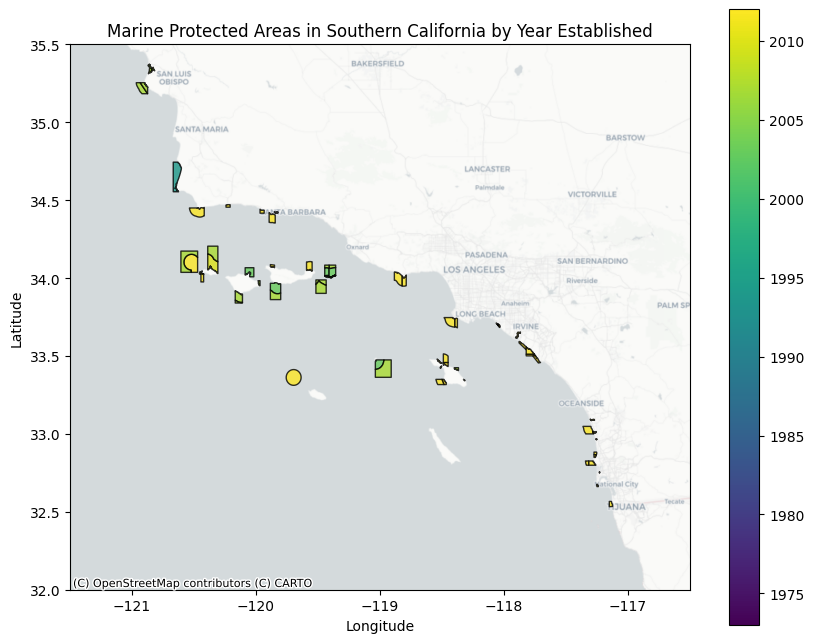

In [7]:
# lets make a map of the MPAs in Southern California using geopandas and contextily
import contextily as cx

merged_gdf = gpd.GeoDataFrame(merged_df, geometry="geometry")

# Plot the MPAs colored by Year Established
ax = merged_gdf.plot(column="Year Established", legend=True, figsize=(10, 8), alpha=0.8, edgecolor='black', cmap='viridis')

# Set axes limits roughly for Southern California (approx: Long -122 to -116, Lat 32 to 35)
ax.set_xlim([-121.5, -116.5])
ax.set_ylim([32.0, 35.5])

# Add a more basic basemap using contextily (CartoDB Positron)
cx.add_basemap(ax, crs=merged_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)

plt.title("Marine Protected Areas in Southern California by Year Established")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
#export the merged dataframe to a new geojson file
merged_gdf.to_file("data/merged_mpa_data.geojson", driver="GeoJSON")



In [5]:
# Download data directly into pandas from the ERDDAP server. 
# Changing the URL extension from .htmlTable to .csv allows pandas to easily read it.
url = "https://oceanview.pfeg.noaa.gov/erddap/tabledap/erdCalCOFIlrvcnt.csv?cruise%2Cship%2Cship_code%2Corder_occupied%2Ctow_type%2Ctow_number%2Cnet_location%2Ctime%2Clatitude%2Clongitude%2Cline%2Cstation%2Cstandard_haul_factor%2Cvolume_sampled%2Cproportion_sorted%2Cscientific_name%2Ccommon_name%2Citis_tsn%2Ccalcofi_species_code%2Clarvae_count%2Clarvae_10m2%2Clarvae_100m3&time%3E=1999-07-01"

# ERDDAP CSVs often have a second row with units. We can skip it using skiprows=[1]
calcofi_df = pd.read_csv(url, skiprows=[1])
print(calcofi_df.info())
calcofi_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 81989 entries, 0 to 81988
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cruise                81989 non-null  int64  
 1   ship                  81989 non-null  str    
 2   ship_code             81989 non-null  str    
 3   order_occupied        81989 non-null  int64  
 4   tow_type              81989 non-null  str    
 5   tow_number            81989 non-null  int64  
 6   net_location          71683 non-null  str    
 7   time                  81989 non-null  str    
 8   latitude              81989 non-null  float64
 9   longitude             81989 non-null  float64
 10  line                  81989 non-null  float64
 11  station               81989 non-null  float64
 12  standard_haul_factor  81989 non-null  float64
 13  volume_sampled        81989 non-null  float64
 14  proportion_sorted     81989 non-null  float64
 15  scientific_name       81989 no

,cruise,ship,ship_code,order_occupied,tow_type,tow_number,net_location,time,latitude,longitude,...,standard_haul_factor,volume_sampled,proportion_sorted,scientific_name,common_name,itis_tsn,calcofi_species_code,larvae_count,larvae_10m2,larvae_100m3
0,199908,NEW HORIZON,NH,1,CB,1,P,1999-08-07T20:19:00Z,32.956665,-117.3,...,3.90,232.8,1.0,Chromis punctipinnis,Blacksmith,170085,626,5,19.5,NaN
1,199908,NEW HORIZON,NH,1,CB,1,P,1999-08-07T20:19:00Z,32.956665,-117.3,...,3.90,232.8,1.0,Engraulis mordax,Northern anchovy,161828,31,5,19.5,NaN
2,199908,NEW HORIZON,NH,1,CB,1,S,1999-08-07T20:19:00Z,32.956665,-117.3,...,3.90,232.8,1.0,Chromis punctipinnis,Blacksmith,170085,626,4,15.6,NaN
3,199908,NEW HORIZON,NH,1,CB,1,S,1999-08-07T20:19:00Z,32.956665,-117.3,...,3.90,232.8,1.0,Engraulis mordax,Northern anchovy,161828,31,3,11.7,NaN
4,199908,NEW HORIZON,NH,1,MT,1,NaN,1999-08-07T19:54:00Z,32.956665,-117.3,...,0.02,73.6,1.0,Chromis punctipinnis,Blacksmith,170085,626,5,NaN,6.793478


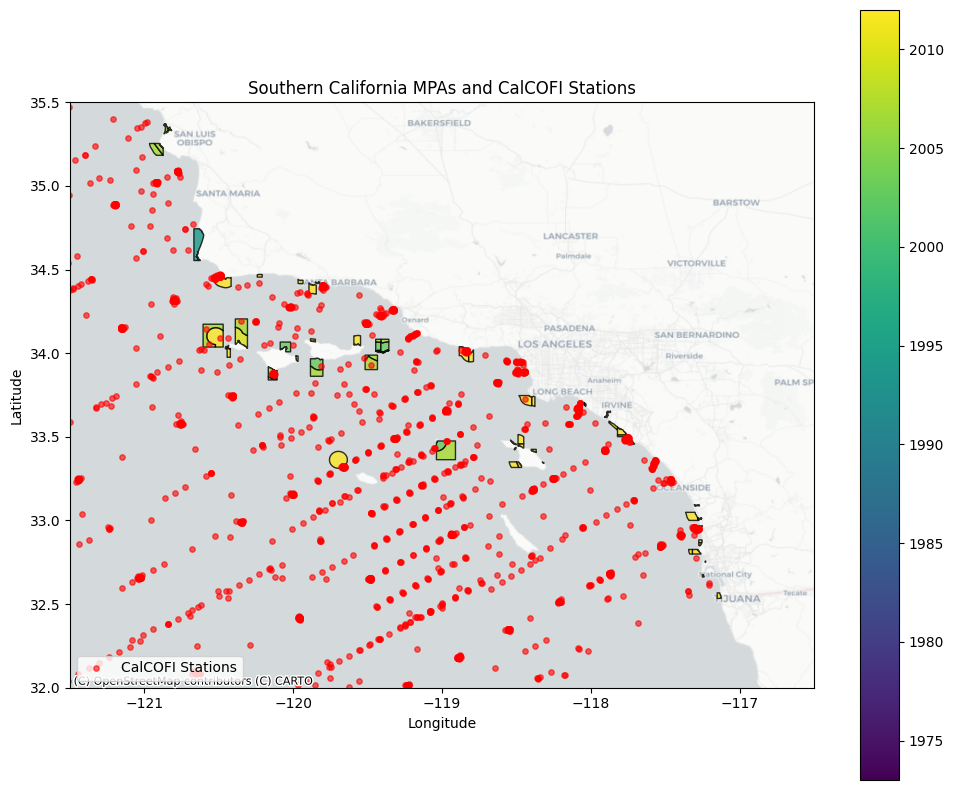

In [7]:
# Extract unique latitude and longitude from calcofi data
unique_coords = calcofi_df[['longitude', 'latitude']].drop_duplicates()

# Convert to a GeoDataFrame
calcofi_gdf = gpd.GeoDataFrame(
    unique_coords, 
    geometry=gpd.points_from_xy(unique_coords.longitude, unique_coords.latitude), 
    crs="EPSG:4326"
)

# Plot the MPAs colored by Year Established
ax = merged_gdf.plot(column="Year Established", legend=True, figsize=(12, 10), alpha=0.8, edgecolor='black', cmap='viridis')

# Overlay the CalCOFI stations
calcofi_gdf.plot(ax=ax, color='red', marker='o', markersize=15, alpha=0.6, label='CalCOFI Stations')

# Set axes limits roughly for Southern California
ax.set_xlim([-121.5, -116.5])
ax.set_ylim([32.0, 35.5])

# Add a more basic basemap using contextily (CartoDB Positron)
import contextily as cx
cx.add_basemap(ax, crs=merged_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)

plt.title("Southern California MPAs and CalCOFI Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Create a legend just for the red scatter points
plt.legend(loc="lower left")

plt.show()

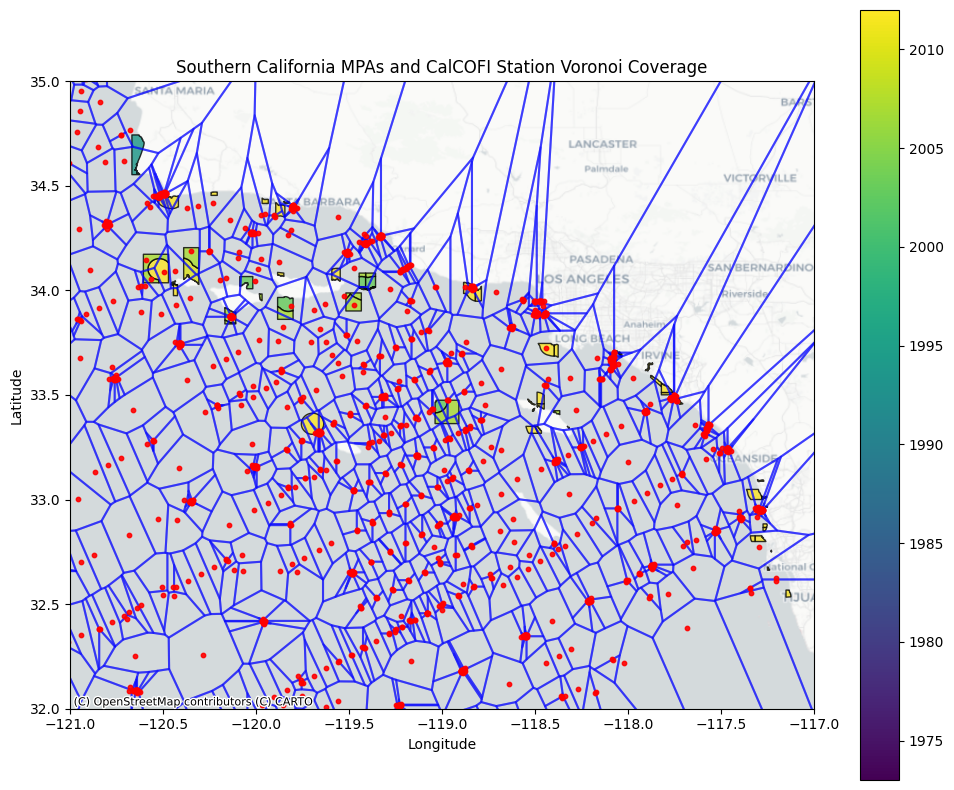

In [10]:
from shapely.ops import voronoi_diagram

# Create a single MultiPoint from all CalCOFI stations
multipoint = calcofi_gdf.geometry.union_all()

# Generate Voronoi Polygons collection using shapely
voronoi_collection = voronoi_diagram(multipoint)

# Extract polygons and convert to a GeoDataFrame
voronoi_gdf = gpd.GeoDataFrame(geometry=list(voronoi_collection.geoms), crs="EPSG:4326")

# Plot MPAs and Voronoi diagram
ax = merged_gdf.plot(column="Year Established", legend=True, figsize=(12, 10), alpha=0.8, edgecolor='black', cmap='viridis')

# Plot Voronoi polygons (no fill, just edges to see coverage)
voronoi_gdf.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=1.5, alpha=0.5, label='Voronoi Coverage')

# Plot the CalCOFI stations
calcofi_gdf.plot(ax=ax, color='red', marker='o', markersize=10, alpha=0.9, label='CalCOFI Stations')

# Set axes limits to specific bounds
ax.set_xlim([-121.0, -117.0])
ax.set_ylim([32.0, 35.0])

# Add a basic basemap
cx.add_basemap(ax, crs=merged_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)

plt.title("Southern California MPAs and CalCOFI Station Voronoi Coverage")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [14]:
# plot overtime 

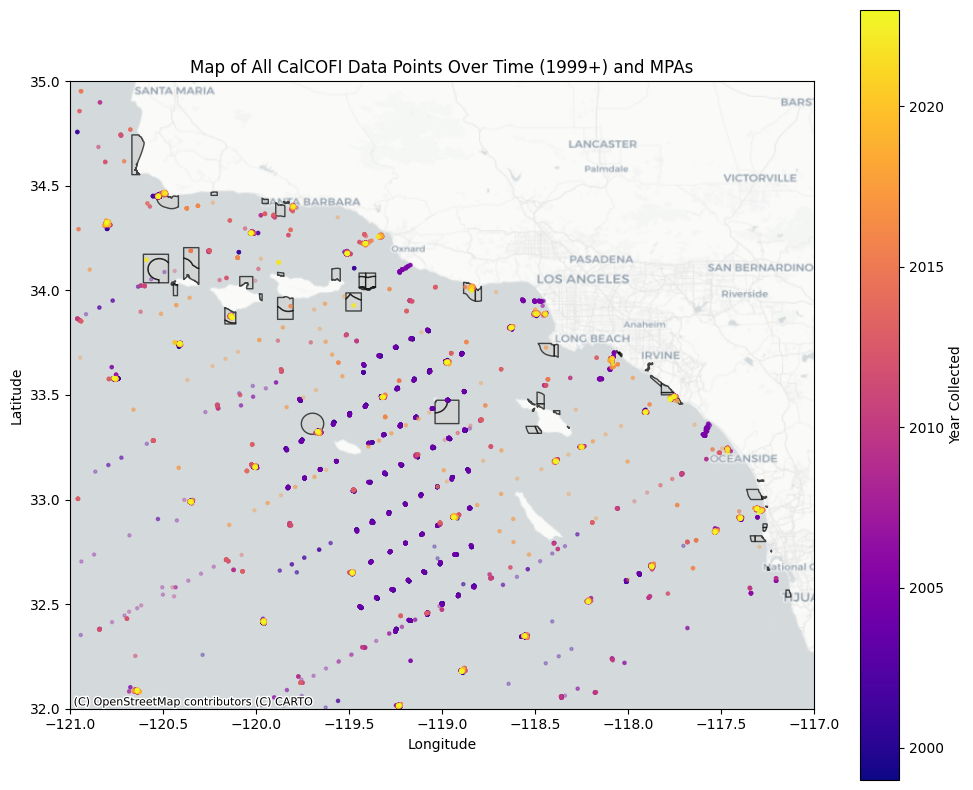

In [8]:
# Convert time to datetime and extract year for a continuous color scale
if 'time' in calcofi_df.columns:
    calcofi_df['datetime'] = pd.to_datetime(calcofi_df['time'])
    calcofi_df['year'] = calcofi_df['datetime'].dt.year

# Create a GeoDataFrame from all original points in the dataset
calcofi_all_gdf = gpd.GeoDataFrame(
    calcofi_df, 
    geometry=gpd.points_from_xy(calcofi_df.longitude, calcofi_df.latitude), 
    crs="EPSG:4326"
)

# Plot the MPAs in a neutral background color so points stand out
ax = merged_gdf.plot(color="lightgrey", edgecolor='black', alpha=0.7, figsize=(12, 10))

# Overlay all original CalCOFI points directly colored by time (year)
calcofi_all_gdf.plot(
    ax=ax, 
    column='year', 
    cmap='plasma', # Good divergent continuous heatmap
    marker='o', 
    markersize=5, 
    alpha=0.3, # Semi-transparent to reveal density overlaps
    legend=True,
    legend_kwds={'label': "Year Collected"}
)

# Set axes limits to Southern California bounds from earlier
ax.set_xlim([-121.0, -117.0])
ax.set_ylim([32.0, 35.0])

# Add a basic basemap
cx.add_basemap(ax, crs=merged_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)

plt.title("Map of All CalCOFI Data Points Over Time (1999+) and MPAs")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [9]:
from ipywidgets import interact, IntSlider
import contextily as cx

# Define a function to plot the map for a specific year
def plot_data_for_year(selected_year):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot the MPAs in the background
    merged_gdf.plot(ax=ax, color="lightgrey", edgecolor='black', alpha=0.7)
    
    # Filter the CalCOFI points for the chosen year
    subset_gdf = calcofi_all_gdf[calcofi_all_gdf['year'] == selected_year]
    
    # Only plot if there's data for this year
    if not subset_gdf.empty:
        subset_gdf.plot(
            ax=ax,
            color='red',
            marker='o',
            markersize=15,
            alpha=0.7,
            label=f'Points in {selected_year}'
        )
        # Add legend
        ax.legend(loc="lower left")
    
    # Set the same Southern California view bounds
    ax.set_xlim([-121.0, -117.0])
    ax.set_ylim([32.0, 35.0])
    
    # Add our basemap
    cx.add_basemap(ax, crs=merged_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)
    
    # Update title to include the dynamically chosen year
    plt.title(f"CalCOFI Points and MPAs in the Year: {selected_year}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    
    plt.show()

# Get the range of years present in our dataset to configure the slider parameters
min_year = int(calcofi_all_gdf['year'].min())
max_year = int(calcofi_all_gdf['year'].max())

# Launch the interactive slider!
interact(plot_data_for_year, selected_year=IntSlider(min=min_year, max=max_year, step=1, value=min_year, description='Year:'))

interactive(children=(IntSlider(value=1999, description='Year:', max=2023, min=1999), Output()), _dom_classes=…

<function __main__.plot_data_for_year(selected_year)>

In [ ]:
from shapely.ops import voronoi_diagram
import shapely.geometry

# Ensure we have a 'month' column extracted from the datetime
if 'month' not in calcofi_all_gdf.columns and 'datetime' in calcofi_all_gdf.columns:
    calcofi_all_gdf['month'] = calcofi_all_gdf['datetime'].dt.month

# Compute the global maximum density to lock the color scale across years
global_voronoi_max = calcofi_all_gdf['larvae_10m2'].max()

def plot_voronoi_for_year(selected_year):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot the MPAs in the background
    merged_gdf.plot(ax=ax, color="lightgrey", edgecolor='black', alpha=0.7)
    
    # Filter the CalCOFI points for the chosen year
    subset_gdf = calcofi_all_gdf[calcofi_all_gdf['year'] == selected_year]
    
    if not subset_gdf.empty:
        # Create a MultiPoint geometry of the current year's data
        multipoint = subset_gdf.geometry.union_all()
        
        # Voronoi diagrams need at least 2 points to form polygons
        if len(subset_gdf) > 1:
            voronoi_collection = voronoi_diagram(multipoint)
            voronoi_gdf = gpd.GeoDataFrame(geometry=list(voronoi_collection.geoms), crs="EPSG:4326")
            
            # Limit the inherently infinite Voronoi polygons to our Southern California bounding box
            view_bbox = shapely.geometry.box(-121.0, 32.0, -117.0, 35.0)
            voronoi_gdf = voronoi_gdf.clip(view_bbox)
            
            # Restrict to ocean by taking the difference against the high-res land geometry 
            if 'unified_land_geom' in globals():
                voronoi_gdf = voronoi_gdf.to_crs(epsg=3310)
                voronoi_gdf['geometry'] = voronoi_gdf.geometry.difference(unified_land_geom)
                voronoi_gdf = voronoi_gdf.to_crs(epsg=4326)
            
            # Perform a spatial join to assign the point attributes (larva density) back to their respective polygon
            voronoi_with_data = gpd.sjoin(voronoi_gdf, subset_gdf[['larvae_10m2', 'geometry']], how="inner", predicate="intersects")
            
            # Plot Voronoi polygons colored by larva density
            voronoi_with_data.plot(
                ax=ax, 
                column='larvae_10m2', 
                cmap='plasma', 
                vmin=0,                         # Fix minimum bound to 0
                vmax=4000,                      # Fix maximum bound globally
                edgecolor="white", 
                linewidth=0.5, 
                alpha=0.7, 
                legend=True,
                legend_kwds={'label': 'Larvae Density (larvae/10m²)'}
            )
            
        # Plot the actual points small and lightly so we can see what generated the cells
        subset_gdf.plot(
            ax=ax,
            color='black',
            marker='.',
            markersize=15,
            alpha=0.6,
            label='Sample Station'
        )
        
    # Set the same Southern California view bounds
    ax.set_xlim([-121.0, -117.0])
    ax.set_ylim([32.0, 35.0])
    
    # Add basemap
    cx.add_basemap(ax, crs=merged_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)
    
    # Title
    plt.title(f"CalCOFI Stations Voronoi Density Map and MPAs in: {selected_year}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    if not subset_gdf.empty:
        plt.legend(loc="lower left")
    plt.show()

# Launch the interactive slider for Voronoi coverage!
interact(plot_voronoi_for_year, selected_year=IntSlider(min=int(min_year), max=int(max_year), step=1, value=int(min_year), description='Year:'))

interactive(children=(IntSlider(value=1999, description='Year:', max=2023, min=1999), Output()), _dom_classes=…

<function __main__.plot_voronoi_for_year(selected_year)>

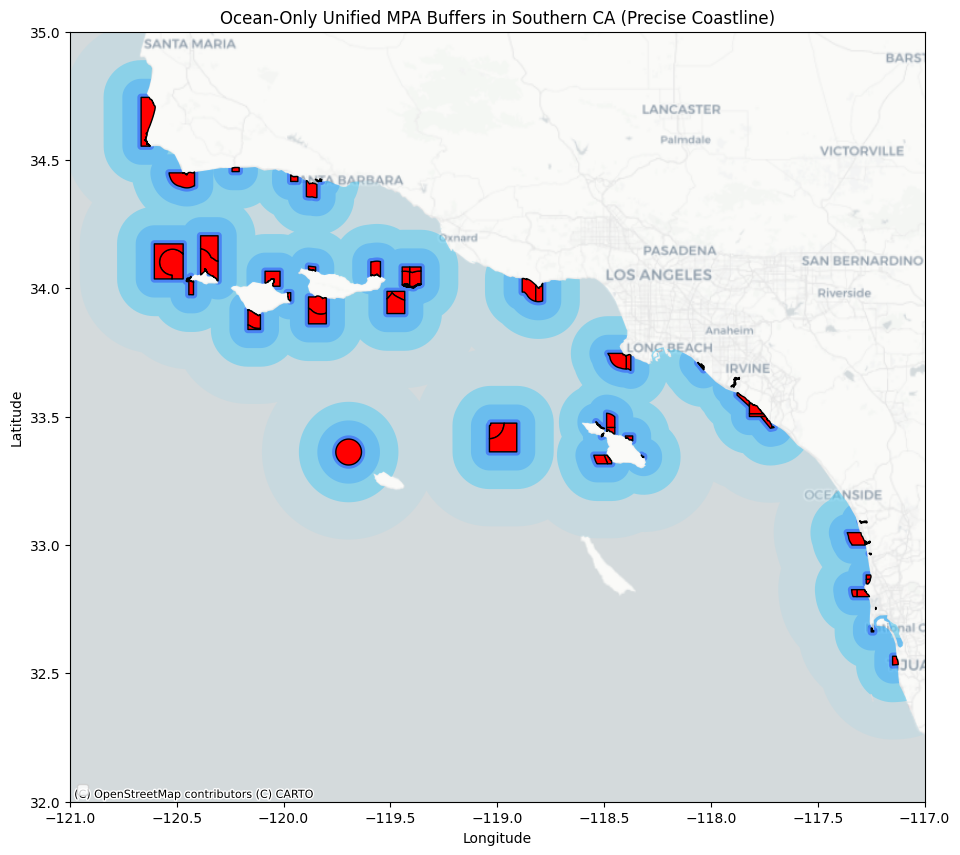

In [27]:
import shapely.geometry
import matplotlib.pyplot as plt
import contextily as cx
import geopandas as gpd
import warnings

# Ignore generic warnings
warnings.filterwarnings('ignore')

# 1. Load high-resolution (10m) country boundaries to better match the visual basemap.
# The previous dataset was extremely blocky/low-res (110m).
url_10m = "zip+https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
try:
    world = gpd.read_file(url_10m)
    name_col = 'ADMIN' if 'ADMIN' in world.columns else 'NAME'
except Exception:
    # Fallback to a stable 50m resolution geojson if the 10m zip download fails
    url_50m = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_50m_admin_0_countries.geojson"
    world = gpd.read_file(url_50m)
    name_col = 'ADMIN' if 'ADMIN' in world.columns else 'NAME'

# Filter to US and Mexico
land = world[world[name_col].isin(['United States of America', 'Mexico', 'United States'])]

# Define our visual bounding box
bbox = shapely.geometry.box(-121.0, 32.0, -117.0, 35.0)

# Crucial scale optimization: since the new coastline is highly detailed, we clip the land to 
# just our focal area (+ a 1 degree safety margin) BEFORE computing the geometric difference.
# This makes the complex math virtually instantaneous instead of taking minutes!
focal_area = bbox.buffer(1.0)
land_cropped = land.clip(focal_area)

# Filter MPAs that intersect the bounding box
mpas_in_bounds = merged_gdf[merged_gdf.intersects(bbox)].copy()

# Reproject to California Albers (EPSG:3310) which uses meters as its unit
mpas_projected = mpas_in_bounds.to_crs(epsg=3310)
land_projected = land_cropped.to_crs(epsg=3310)

# Combine all geometries into single multipolygons
unified_mpas_geom = mpas_projected.geometry.union_all()
unified_land_geom = land_projected.geometry.union_all()

# 1 mile = 1609.34 meters
miles_to_meters = 1609.34
buffer_distances = [1, 5, 10, 20]

mpa_buffers = {}

for distance in buffer_distances:
    # Buffer the single unified MPA geometry
    buffered_geom = unified_mpas_geom.buffer(distance * miles_to_meters)
    
    # Restrict to ocean by cleanly cutting away the highly detailed land
    ocean_only_geom = buffered_geom.difference(unified_land_geom)
    
    # Store back to a new GeoDataFrame and reproject back to original CRS
    buffer_gdf = gpd.GeoDataFrame(geometry=[ocean_only_geom], crs="EPSG:3310")
    mpa_buffers[distance] = buffer_gdf.to_crs(epsg=4326)

# Plot the results
fig, ax = plt.subplots(figsize=(12, 10))

# Plot largest buffer to smallest so they stack visually
colors = {20: 'lightblue', 10: 'deepskyblue', 5: 'dodgerblue', 1: 'blue'}
for distance in sorted(buffer_distances, reverse=True):
    mpa_buffers[distance].plot(ax=ax, color=colors[distance], alpha=0.3, label=f'{distance} mi ocean buffer')

# Plot the original MPAs inside the bounds in red
mpas_in_bounds.plot(ax=ax, color='red', edgecolor='black', label='MPAs', zorder=5)

# Set the limits to our bounding box
ax.set_xlim([-121.0, -117.0])
ax.set_ylim([32.0, 35.0])

# Add the original high-quality visual basemap back!
cx.add_basemap(ax, crs=mpas_in_bounds.crs.to_string(), source=cx.providers.CartoDB.Positron)

plt.title("Ocean-Only Unified MPA Buffers in Southern CA (Precise Coastline)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="lower left")

plt.show()

In [28]:
from ipywidgets import interact, IntSlider
import contextily as cx

# 1. Convert the unified MPA shape back to latitude/longitude (EPSG:4326) to match CalCOFI data
unified_mpas_4326 = gpd.GeoSeries([unified_mpas_geom], crs="EPSG:3310").to_crs(epsg=4326).iloc[0]

# 2. Initialize a new column for the buffer zone as "Outside"
calcofi_all_gdf['buffer_zone'] = 'Outside'

# 3. Bin the points (assigning from largest buffer to smallest, so smaller distances cleanly overwrite larger ones)
for dist in sorted(buffer_distances, reverse=True):
    poly = mpa_buffers[dist].geometry.iloc[0]
    # Check if CalCOFI points fall within the buffer polygon
    calcofi_all_gdf.loc[calcofi_all_gdf.geometry.within(poly), 'buffer_zone'] = f'{dist} mile'

# 4. Finally, mark the points actually strictly inside the original MPAs
calcofi_all_gdf.loc[calcofi_all_gdf.geometry.within(unified_mpas_4326), 'buffer_zone'] = 'Inside MPA'

# 5. Define matching discrete colors for each zone for visual cohesion
zone_colors = {
    'Inside MPA': 'red',
    '1 mile': 'blue',
    '5 mile': 'dodgerblue',
    '10 mile': 'deepskyblue',
    '20 mile': 'lightblue',
    'Outside': 'gray'
}

def plot_binned_for_year(selected_year):
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Draw the background geometry buffers faintly to frame our zones
    buffer_cmap = {20: 'lightblue', 10: 'deepskyblue', 5: 'dodgerblue', 1: 'blue'}
    for dist in sorted(buffer_distances, reverse=True):
        mpa_buffers[dist].plot(ax=ax, color=buffer_cmap[dist], alpha=0.15, zorder=1)
        
    mpas_in_bounds.plot(ax=ax, color='red', edgecolor='black', alpha=0.2, zorder=2)
    
    # Filter CalCOFI data for the specific chosen year on the slider
    subset_gdf = calcofi_all_gdf[calcofi_all_gdf['year'] == selected_year]
    
    # Plot the separated binned points directly on top of the map layer
    if not subset_gdf.empty:
        # Plot in order from outside-in to ensure smaller buffers plot on top
        for zone in ['Outside', '20 mile', '10 mile', '5 mile', '1 mile', 'Inside MPA']:
            zone_data = subset_gdf[subset_gdf['buffer_zone'] == zone]
            if not zone_data.empty:
                zone_data.plot(
                    ax=ax,
                    color=zone_colors[zone],
                    marker='o',
                    markersize=40 if zone != 'Outside' else 15,
                    edgecolor='black',
                    linewidth=0.5,
                    alpha=0.9,
                    label=zone,
                    zorder=3
                )
        # Deduplicate legend
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), title="Station Location", loc="lower left")
        
    # Snap the camera to Southern California
    ax.set_xlim([-121.0, -117.0])
    ax.set_ylim([32.0, 35.0])
    
    cx.add_basemap(ax, crs=calcofi_all_gdf.crs.to_string(), source=cx.providers.CartoDB.Positron)
    
    plt.title(f"CalCOFI Stations Binned by MPA Ocean Buffer Zone in: {selected_year}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

# Launch interactive slider just like cell 15
interact(plot_binned_for_year, selected_year=IntSlider(min=int(min_year), max=int(max_year), step=1, value=int(min_year), description='Year:'))

interactive(children=(IntSlider(value=1999, description='Year:', max=2023, min=1999), Output()), _dom_classes=…

<function __main__.plot_binned_for_year(selected_year)>

In [37]:
import matplotlib.colors as mcolors

# 1. Pre-calculate the non-overlapping "ring" geometries for accurate density coloring
# We skip the 1-mile buffer here and just let the 5-mile buffer extend to the MPA boundary
rings_geom = {}
rings_geom['20 mile'] = mpa_buffers[20].geometry.iloc[0].difference(mpa_buffers[10].geometry.iloc[0])
rings_geom['10 mile'] = mpa_buffers[10].geometry.iloc[0].difference(mpa_buffers[5].geometry.iloc[0])
rings_geom['5 mile'] = mpa_buffers[5].geometry.iloc[0].difference(unified_mpas_4326)
rings_geom['Inside MPA'] = unified_mpas_4326

rings_gdf = gpd.GeoDataFrame(
    geometry=list(rings_geom.values()), 
    index=list(rings_geom.keys()), 
    crs="EPSG:4326"
)

# Replace '1 mile' with '5 mile' in a temporary dataframe so we can correctly compute density
density_df = calcofi_all_gdf.copy()

# Ensure we have a month column and filter to only January (1) through May (5)
if 'month' not in density_df.columns and 'datetime' in density_df.columns:
    density_df['month'] = density_df['datetime'].dt.month
density_df = density_df[density_df['month'].between(1, 5)]

density_df['plot_zone'] = density_df['buffer_zone'].replace({'1 mile': '5 mile'})

# Compute the global maximum density across all valid zones and years to lock the color scale
valid_zones = ['20 mile', '10 mile', '5 mile', 'Inside MPA']
global_max_density = density_df[density_df['plot_zone'].isin(valid_zones)].groupby(['year', 'plot_zone'])['larvae_10m2'].mean().max()

def plot_density_for_year(selected_year):
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Filter for the chosen year
    subset = density_df[density_df['year'] == selected_year]
    
    # Calculate the average larva density per buffer zone for this year
    if not subset.empty:
        density_by_zone = subset.groupby('plot_zone')['larvae_10m2'].mean()
    else:
        density_by_zone = pd.Series(dtype=float)
    
    # Merge the calculated density back into our rings GeoDataFrame
    plot_gdf = rings_gdf.copy()
    plot_gdf['density'] = plot_gdf.index.map(density_by_zone).fillna(0)
    
    # Plot the rings with a constant color scale (vmin and vmax locked)
    if global_max_density > 0:
        plot_gdf.plot(
            ax=ax, 
            column='density', 
            cmap='YlOrRd',          
            alpha=0.8, 
            vmin=0,                        # Lock minimum to 0
            vmax=global_max_density,       # Lock maximum to the highest overall average density
            legend=True,
            legend_kwds={'label': 'Average Larvae / 10m²', 'orientation': 'vertical'}
        )
    else:
        plot_gdf.plot(ax=ax, color='lightgray', alpha=0.5)
        
    # Draw the original points in the background for context
    if not subset.empty:
        inside_points = subset[subset['plot_zone'] != 'Outside']
        if not inside_points.empty:
            inside_points.plot(
                ax=ax, color='black', marker='.', markersize=5, alpha=0.4, label="Sample Stations"
            )
        
    # Draw simple black boundaries
    plot_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.5)
        
    # Set the familiar Southern California view bounds
    ax.set_xlim([-121.0, -117.0])
    ax.set_ylim([32.0, 35.0])
    
    # Add carto basemap
    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
    
    plt.title(f"Average Larva Density by MPA Buffer Zone in: {selected_year}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    if not subset.empty and not inside_points.empty:
        plt.legend(loc="lower left")
    plt.show()

# Launch interactive slider!
interact(plot_density_for_year, selected_year=IntSlider(min=int(min_year), max=int(max_year), step=1, value=int(min_year), description='Year:'))

interactive(children=(IntSlider(value=1999, description='Year:', max=2023, min=1999), Output()), _dom_classes=…

<function __main__.plot_density_for_year(selected_year)>